## Correlation and Linear Regression


#### we want to see how the iNaturalist observation is impacted by behavior / environmental factors. 

<b>Hypothesis</b> - The pattern of data collection is more influenced by the behavior of participants than by the population, environmental factors, such as green and blue space and other events. 

Data : 
<ul>
 <li>iNaturalist observations (2016-2023)</li>
 <li>poulation density Estimated population density per grid-cell. The dataset is available to download in Geotiff and ASCII XYZ format at a resolution of 30 arc (approximately 1km at the equator). The projection is Geographic Coordinate System, WGS84</li>
 <li>presence of green space/blue space downloaded using OSM tags</li>
</ul>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import seaborn as sns
import os
import numpy as np

# Getting the Data

In [2]:
path = '/Users/zahrafarook/Desktop/DataAnalysis/ExpectationSurface/'
dir_list = os.listdir(path)
print(dir_list)

['QGIS files', '.DS_Store', '`Expectation Surface-Copy1.ipynb', '`Expectation Surface _ SF.ipynb', 'Sri_Lanka', 'ES_with_PD', 'Bolivia', 'San_Francisco', '.ipynb_checkpoints', 'London']


In [3]:
df = pd.read_csv("/Users/zahrafarook/Desktop/DataAnalysis/ExpectationSurface/ES_with_PD/Sri_Lanka/ES_gr_bl_colombo_final.csv")

In [4]:
df.head()

,id,left,top,right,bottom,row_index,col_index,area,X,Y,...,expected,actual,chi_square,blue_count,green_coun,has_green,has_blue,bl_ar_m2,gr_ar_m2,surface_gb
0,2,372739.6656,770369.7619,373739.6656,769369.7619,1,0,485290,79.852916,6.962084,...,25.0,0,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg
1,3,372739.6656,769369.7619,373739.6656,768369.7619,2,0,983168,79.852916,6.953750,...,32.0,1,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg
2,4,372739.6656,768369.7619,373739.6656,767369.7619,3,0,985594,79.852916,6.945417,...,103.0,5,-10.0,NaN,NaN,0,0,NaN,NaN,NoneNeg
3,5,372739.6656,767369.7619,373739.6656,766369.7619,4,0,988020,79.852916,6.937084,...,67.0,17,-6.0,2.0,3.0,1,1,462342.0,66754.0,GBNeg
4,6,372739.6656,766369.7619,373739.6656,765369.7619,5,0,990445,79.852916,6.928750,...,23.0,10,-3.0,2.0,5.0,1,1,553657.0,93948.0,GBNeg


# Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          762 non-null    int64  
 1   left        762 non-null    float64
 2   top         762 non-null    float64
 3   right       762 non-null    float64
 4   bottom      762 non-null    float64
 5   row_index   762 non-null    int64  
 6   col_index   762 non-null    int64  
 7   area        762 non-null    int64  
 8   X           686 non-null    float64
 9   Y           686 non-null    float64
 10  Z           686 non-null    float64
 11  expected    686 non-null    float64
 12  actual      762 non-null    int64  
 13  chi_square  674 non-null    float64
 14  blue_count  360 non-null    float64
 15  green_coun  360 non-null    float64
 16  has_green   762 non-null    int64  
 17  has_blue    762 non-null    int64  
 18  bl_ar_m2    360 non-null    float64
 19  gr_ar_m2    360 non-null    f

In [6]:
df.describe()

,id,left,top,right,bottom,row_index,col_index,area,X,Y,Z,expected,actual,chi_square,blue_count,green_coun,has_green,has_blue,bl_ar_m2,gr_ar_m2
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,7.620000e+02,686.000000,686.000000,686.000000,686.000000,762.000000,674.000000,360.000000,360.000000,762.000000,762.000000,3.600000e+02,3.600000e+02
mean,567.035433,391214.731217,759586.297333,392214.731217,758586.297333,11.783465,18.475066,8.919319e+05,80.019680,6.869190,3542.385966,17.373178,15.649606,0.537092,1.950000,1.605556,0.262467,0.371391,1.659525e+06,3.599193e+04
std,348.061061,11657.171759,6295.532869,11657.171759,6295.532869,6.295533,11.657172,2.612146e+05,0.104790,0.053182,3991.134633,19.570366,55.984434,15.829026,2.525138,3.146377,0.440264,0.483494,3.783054e+06,1.475069e+05
min,2.000000,372739.665600,742369.761900,373739.665600,741369.761900,0.000000,0.000000,4.810000e+02,79.852916,6.728750,44.252960,0.000000,0.000000,-12.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,260.250000,380739.665600,754369.761900,381739.665600,753369.761900,7.000000,8.000000,1.000409e+06,79.927916,6.828750,848.239456,4.000000,0.000000,-4.000000,1.000000,0.000000,0.000000,0.000000,9.592500e+02,0.000000e+00
50%,524.500000,389739.665600,759369.761900,390739.665600,758369.761900,12.000000,17.000000,1.000471e+06,80.002916,6.870417,2409.520264,12.000000,1.000000,-2.000000,1.000000,1.000000,0.000000,0.000000,6.140200e+04,1.539500e+03
75%,883.750000,401739.665600,764369.761900,402739.665600,763369.761900,17.000000,29.000000,1.000539e+06,80.111250,6.912084,4668.892334,23.000000,6.000000,-1.000000,2.000000,2.000000,1.000000,1.000000,7.310408e+05,1.325750e+04
max,1234.000000,413739.665600,771369.761900,414739.665600,770369.761900,29.000000,41.000000,1.000614e+06,80.219583,6.970417,32657.751953,160.000000,944.000000,281.000000,20.000000,37.000000,1.000000,1.000000,1.337375e+07,1.115814e+06


In [7]:
df.isnull().sum()

id              0
left            0
top             0
right           0
bottom          0
row_index       0
col_index       0
area            0
X              76
Y              76
Z              76
expected       76
actual          0
chi_square     88
blue_count    402
green_coun    402
has_green       0
has_blue        0
bl_ar_m2      402
gr_ar_m2      402
surface_gb      0
dtype: int64

In [8]:
#we are only remove the rows with NULL in Population density(Z)
df_clean = df.dropna(subset=['Z']).copy()

In [9]:
df_clean.isnull().sum()

id              0
left            0
top             0
right           0
bottom          0
row_index       0
col_index       0
area            0
X               0
Y               0
Z               0
expected        0
actual          0
chi_square     12
blue_count    354
green_coun    354
has_green       0
has_blue        0
bl_ar_m2      354
gr_ar_m2      354
surface_gb      0
dtype: int64

In [10]:
print(f"Rows remaining after subset removal: {len(df_clean)}")


Rows remaining after subset removal: 686


### Check the Distribution 

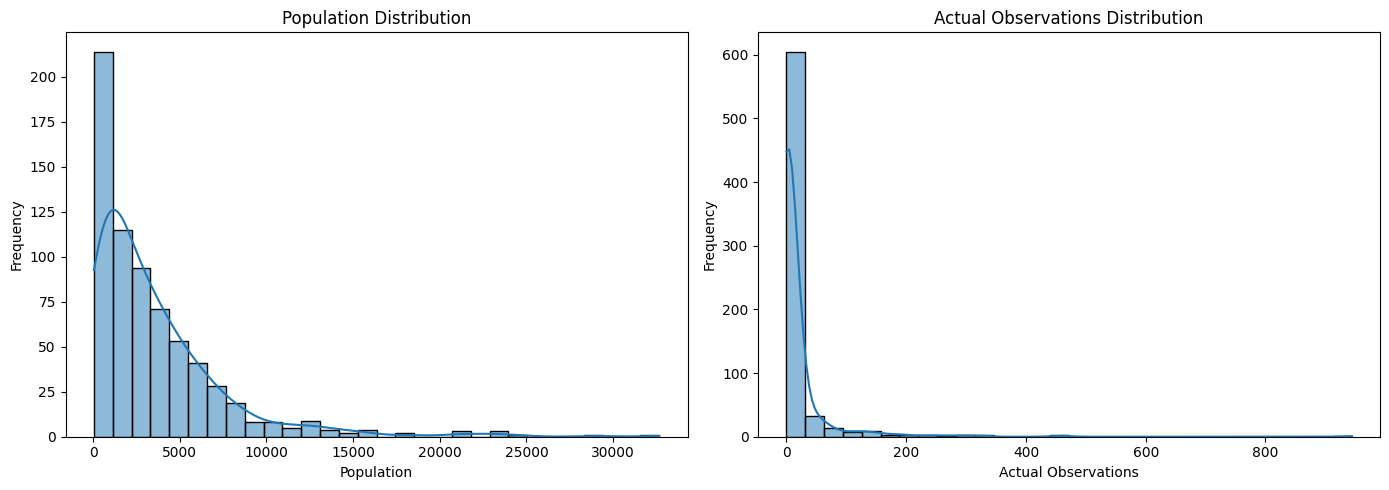

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for 'population density'
sns.histplot(df_clean['Z'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Population Distribution')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Frequency')

# Histogram for 'actual' (number of observations)
sns.histplot(df_clean['actual'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Actual Observations Distribution')
axes[1].set_xlabel('Actual Observations')
axes[1].set_ylabel('Frequency')



plt.tight_layout()
plt.show()

<p> Since the observation is skewed, we are doing the log transformation here.</p>

In [12]:
# log tranformation

In [13]:
df_clean = df_clean.copy()
df_clean['log_actual'] = np.log1p(df_clean['actual'])

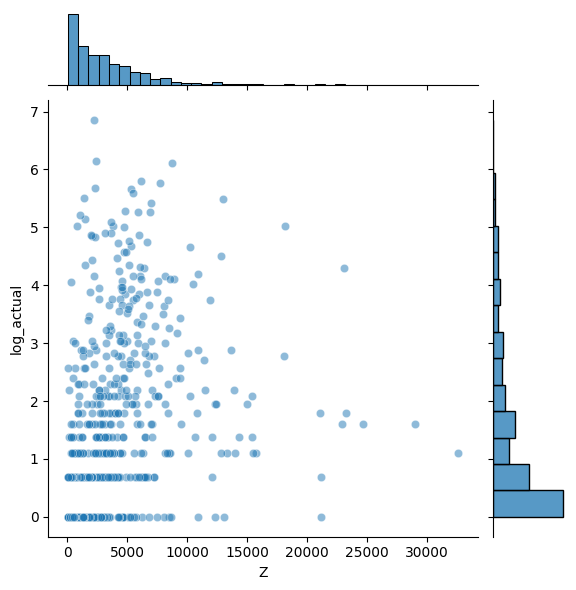

In [14]:
# observation vs population 
#sns.jointplot(x='actual', y='Z', data=df, alpha=0.5)
sns.jointplot(data=df_clean, x="Z", y="log_actual",alpha=0.5)


In [15]:
#sns.pairplot(df, hue="actual")

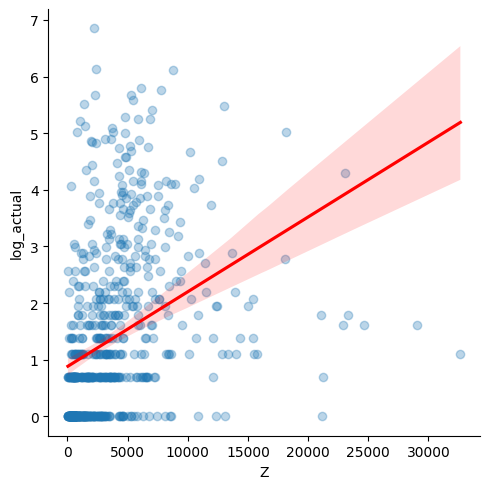

In [16]:
# 
sns.lmplot(x='Z', 
           y='log_actual', 
           data=df_clean,
           scatter_kws={'alpha':0.3},line_kws={'color':'red'})

# Correlation Analysis

<p> Here we see the individual linear relationship between the dependent variable (observation , log transfered), and each of the independent variables (population density, green, blue space).</p>



In [17]:
from scipy.stats import pearsonr


### correlation , p value for observation and population density


In [18]:
def cor_coeffand_p_v(df):
    correlation, p_value = pearsonr(df['Z'], df['log_actual'])
    print(f"Pearson Correlation: {correlation:.3f}, P-value: {p_value:.3f}")
    return correlation, p_value


In [19]:
correlation, p_val = cor_coeffand_p_v(df_clean)

Pearson Correlation: 0.353, P-value: 0.000


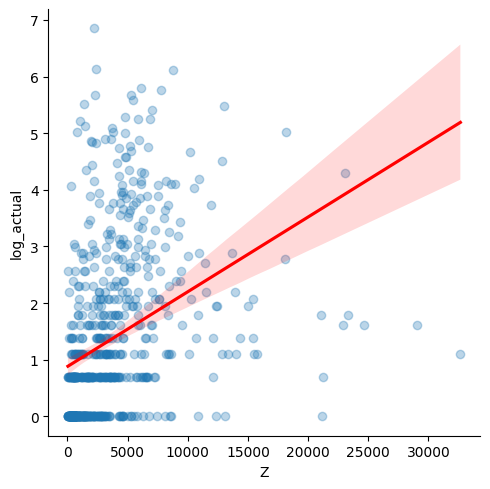

In [20]:
sns.lmplot(x='Z', 
           y='log_actual', 
           data=df_clean,
           scatter_kws={'alpha':0.3},line_kws={'color':'red'})

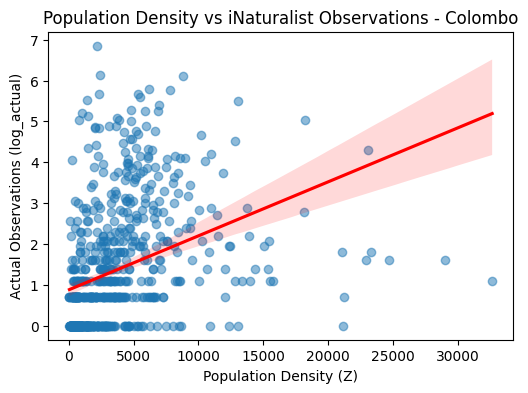

In [21]:
plt.figure(figsize=(6, 4))
sns.regplot(x='Z', y='log_actual', data=df_clean, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('Population Density (Z)')
plt.ylabel('Actual Observations (log_actual)')
plt.title('Population Density vs iNaturalist Observations - Colombo')

plt.show()


### correlation , p value for observation and green and blue space


In [22]:
r_green, p_green = pearsonr(df_clean['has_green'], df_clean['log_actual'])
r_blue, p_blue = pearsonr(df_clean['has_blue'], df_clean['log_actual'])
print ('Pearson Correlation and P-value of :')
print(f"Greenspace  : r={r_green:.3f}, p={p_green:.3f}")
print(f"Blue space : r={r_blue:.3f}, p={p_blue:.3f}")

Pearson Correlation and P-value of :
Greenspace  : r=0.436, p=0.000
Blue space : r=0.244, p=0.000


def cor_coeffand_p_v_gr(df):
    """
    Calculates the Pearson correlation and P-value between 'gr_area_m2' 
    and 'log_actual' after removing rows with null values in either column.
    """
    temp_df = df_clean.dropna(subset=['has_green', 'log_actual']).copy()
    # Calculate correlation on the cleaned data
    correlation, p_value = pearsonr(temp_df['has_green'], temp_df['log_actual'])
    print(f"Pearson Correlation: {correlation:.3f}, P-value: {p_value:.3f}")
    return correlation, p_value
   
 correlation, p_val = cor_coeffand_p_v_gr(df_clean)

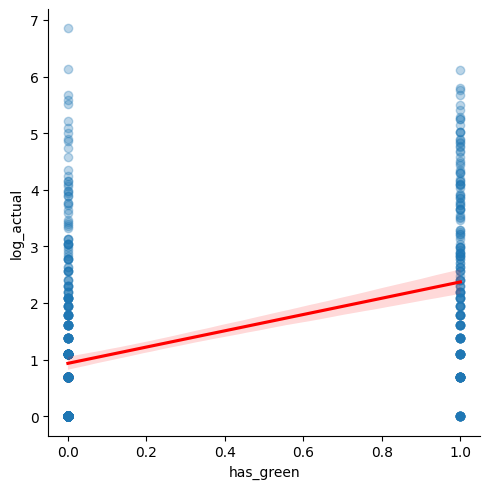

In [23]:
sns.lmplot(x='has_green', 
           y='log_actual', 
           data=df_clean,
           scatter_kws={'alpha':0.3},line_kws={'color':'red'})

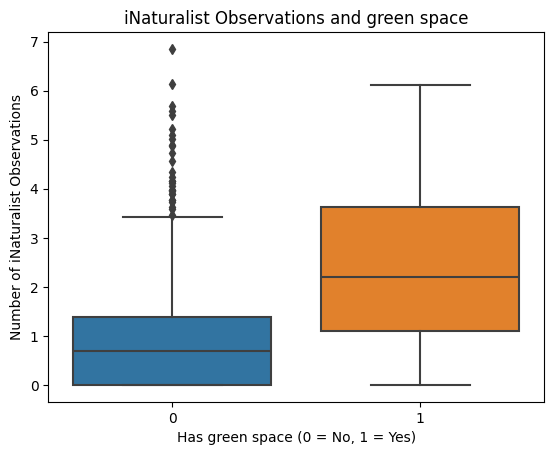

In [24]:
sns.boxplot(x='has_green', y='log_actual', data=df_clean)
plt.xlabel('Has green space (0 = No, 1 = Yes)')
plt.ylabel('Number of iNaturalist Observations')
plt.title('iNaturalist Observations and green space')
plt.show()

## Splitting the data
X are the predictores, and y is the output. The model  will take in the values in the X variable and predict y with a linear regression algorithm using scikit l.
We will use the SciKit Learn library to create the model.

In [25]:
from sklearn.model_selection import train_test_split


In [26]:
 df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 686 entries, 0 to 760
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          686 non-null    int64  
 1   left        686 non-null    float64
 2   top         686 non-null    float64
 3   right       686 non-null    float64
 4   bottom      686 non-null    float64
 5   row_index   686 non-null    int64  
 6   col_index   686 non-null    int64  
 7   area        686 non-null    int64  
 8   X           686 non-null    float64
 9   Y           686 non-null    float64
 10  Z           686 non-null    float64
 11  expected    686 non-null    float64
 12  actual      686 non-null    int64  
 13  chi_square  674 non-null    float64
 14  blue_count  332 non-null    float64
 15  green_coun  332 non-null    float64
 16  has_green   686 non-null    int64  
 17  has_blue    686 non-null    int64  
 18  bl_ar_m2    332 non-null    float64
 19  gr_ar_m2    332 non-null    f

###  Does a larger population lead to more observations?

In [27]:
X =  df_clean[['Z']] #Independent Variable (X)
y =  df_clean['log_actual'] #ddependent Variable (y)

In [28]:
X.head()
y.head()

0    0.000000
1    0.693147
2    1.791759
3    2.890372
4    2.397895
Name: log_actual, dtype: float64

<p> split the data into two parts. 70:30 </p>

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

## Training the Model with single variable and mulivariable regression

In this section, we create the model and feed the training data to it. <br> This model will tell us which input has the biggest impact in the output (observation)</br>.

### Signle Variable (Population vs Observation)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lm = LinearRegression()

In [32]:
lm.fit(X_train,y_train)

LinearRegression()

In [33]:
lm.coef_

array([0.00013344])

In [34]:
# the coefficients
lm.coef_

array([0.00013344])

In [35]:
# r squared
lm.score(X, y)

0.12417095522530042

In [36]:
# The coefficients in a dataframe
cdf = pd.DataFrame(lm.coef_,X.columns,columns=['Coef'])
print(cdf)

       Coef
Z  0.000133


## Training the model with regression using OLS


### Single variable - population density

In [37]:
import statsmodels.api as sm

In [38]:
X = sm.add_constant(X_train)
model = sm.OLS(y_train, X)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     60.10
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           5.48e-14
Time:                        23:13:48   Log-Likelihood:                -846.33
No. Observations:                 480   AIC:                             1697.
Df Residuals:                     478   BIC:                             1705.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8968      0.086     10.402      0.0

## Predicting Test Data
Now that the model is trained, 
we should be able to use it to make our predictions and evaluate our model. 
The scatter plot below plots the actual y values to the model's predictions. 

In [39]:
predictions = lm.predict(X_test)

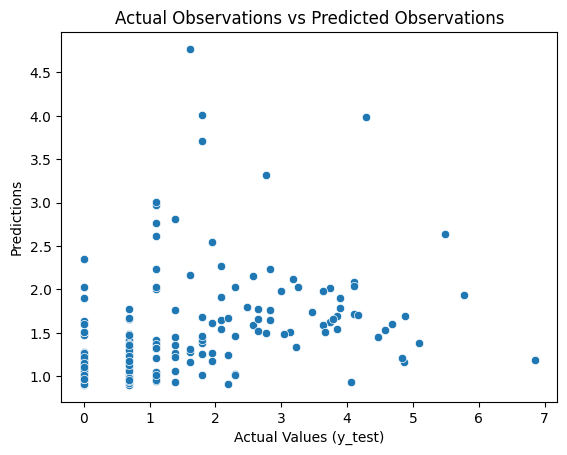

In [40]:

sns.scatterplot(x=y_test, y=predictions) 
plt.xlabel('Actual Values (y_test)') # Added x-label for clarity
plt.ylabel('Predictions')
plt.title('Actual Observations vs Predicted Observations') 
plt.show() # Added show() to display the plot

## Evaluation of the model

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [42]:
print('Mean Absolute Error:',mean_absolute_error(y_test, predictions))
print('Mean Squared Error:',mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 1.08214352079783
Mean Squared Error: 1.8629374120482305
Root Mean Squared Error: 1.3648946523626762


## Residuals
### Distribution plot of the residuals of the model's predictions. They should be normally distributed.

In [43]:
import pylab 
import scipy.stats as stats

<Axes: xlabel='log_actual', ylabel='Count'>

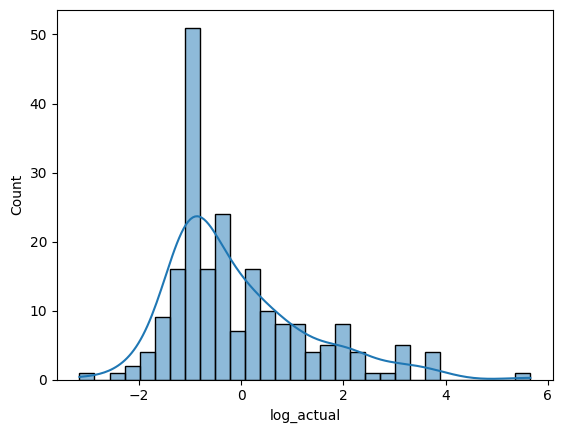

In [44]:
residuals = y_test-predictions
sns.histplot(residuals, bins=30,kde=True)

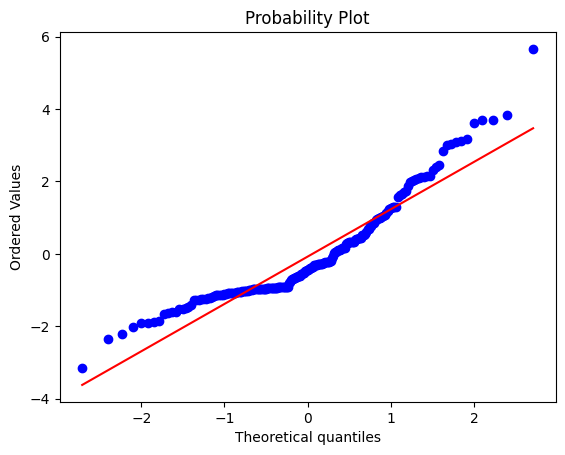

In [45]:
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [46]:
residuals

317    0.113367
719   -1.024179
287   -0.629984
372   -1.248032
352    3.703382
         ...   
234    0.295251
663   -0.971461
78    -1.511594
16    -1.902658
745    0.329875
Name: log_actual, Length: 206, dtype: float64

## Moran 1 Spatial AutoCorrelation

In [47]:
import libpysal.weights as lpw  
from esda.moran import Moran   

In [48]:
pip install pysal

Note: you may need to restart the kernel to use updated packages.


In [49]:
import libpysal.weights as lpw
from esda.moran import Moran 

In [50]:
import geopandas as gpd

In [51]:
gdf = gpd.read_file('ES_GR_BL_Final.shp')
gdf

,id,left,top,right,bottom,row_index,col_index,area,X,Y,...,chi_square,blue_count,green_coun,has_green,has_blue,bl_ar_m2,gr_ar_m2,surface_gb,chi_clean,geometry
0,2.0,372739.6656,770369.7619,373739.6656,769369.7619,1.0,0.0,485290,79.852916,6.962084,...,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-5,"POLYGON ((373739.666 769696.326, 373739.666 76..."
1,3.0,372739.6656,769369.7619,373739.6656,768369.7619,2.0,0.0,983168,79.852916,6.953750,...,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-5,"POLYGON ((372758.105 769369.762, 373739.666 76..."
2,4.0,372739.6656,768369.7619,373739.6656,767369.7619,3.0,0.0,985594,79.852916,6.945417,...,-10.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-10,"POLYGON ((372755.680 768369.762, 373739.666 76..."
3,5.0,372739.6656,767369.7619,373739.6656,766369.7619,4.0,0.0,988020,79.852916,6.937084,...,-6.0,2.0,3.0,1,1,462342.0,66754.0,GBNeg,-6,"POLYGON ((372753.256 767369.762, 373739.666 76..."
4,6.0,372739.6656,766369.7619,373739.6656,765369.7619,5.0,0.0,990445,79.852916,6.928750,...,-3.0,2.0,5.0,1,1,553657.0,93948.0,GBNeg,-3,"POLYGON ((372750.831 766369.762, 373739.666 76..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,1204.0,412739.6656,768369.7619,413739.6656,767369.7619,3.0,40.0,804913,80.211250,6.945417,...,-3.0,1.0,1.0,1,1,1085.0,2303.0,GBNeg,-3,"POLYGON ((413090.371 767369.762, 412739.666 76..."
758,1205.0,412739.6656,767369.7619,413739.6656,766369.7619,4.0,40.0,57094,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NoData,0,"POLYGON ((412739.666 767044.365, 412739.666 76..."
759,1232.0,413739.6656,770369.7619,414739.6656,769369.7619,1.0,41.0,18931,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NoData,0,"POLYGON ((413819.543 769369.762, 413739.666 76..."
760,1233.0,413739.6656,769369.7619,414739.6656,768369.7619,2.0,41.0,164292,80.219583,6.953750,...,-4.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-4,"POLYGON ((413988.170 768369.762, 413739.666 76..."


In [62]:
X_train_full.shape

(686, 1)

In [64]:
import statsmodels.api as sm

X_train_full = df_clean[['Z']]
Y_train_full = df_clean['log_actual'] 

New Model Coeffs Shape: (2,)


In [67]:
X_all = sm.add_constant(X_train_full)
model_all = sm.OLS(Y_train_full, X_all)
model_fit_all = model_all.fit()
print(model_fit_all.summary())

                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     97.20
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           1.58e-21
Time:                        23:20:13   Log-Likelihood:                -1202.8
No. Observations:                 686   AIC:                             2410.
Df Residuals:                     684   BIC:                             2419.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8789      0.071     12.302      0.0

In [76]:
residuals_all = Y_train_full - predictions_full
residuals_all


0     -1.545832
1     -1.053745
2     -1.869228
3      0.201235
4      0.908979
         ...   
754   -0.952204
755    0.796573
756    0.152153
757    0.186356
760   -1.253128
Length: 686, dtype: float64

In [77]:
residual_df = pd.DataFrame(residuals_all, columns=['residual_val'])

# Merge with the full Geodf
gdf_aligned = gdf.merge(residual_df, left_index=True, right_index=True, how='left')

# The full residual column now exists, but has 76 NaNs
full_residuals_column = gdf_aligned['residual_val']

In [84]:

#Filter the GeoDataFrame and the Residuals y)

clean_indices = full_residuals_column.dropna().index 

# Filter the gdf down to only the 686 cells that were included in the OLS model
gdf_clean = gdf.loc[clean_indices] 

# Filter the residuals to only the 686 non-NaN values
residuals_clean = full_residuals_column.dropna()

# Ensure residuals are a NumPy array for Moran's I
residuals_final = np.asarray(residuals_clean).reshape(len(residuals_clean), 1)

#  Spatial Weights Matrix (W)
W = lpw.Queen.from_dataframe(gdf_clean)
W.transform = 'R'

# Calculate Global Moran's I
moran = Moran(residuals_final, W)

# 4. Print Results
print("--- Global Moran's I Test Results (on OLS Residuals) ---")
print(f"Moran's I Statistic (I): {moran.I:.4f}")
print(f"P-value (P_sim): {moran.p_sim:.4f}")
print(f"Z-Score (Z_sim): {moran.z_sim:.4f}")
print("--------------------------------------------------")

--- Global Moran's I Test Results (on OLS Residuals) ---
Moran's I Statistic (I): 0.3527
P-value (P_sim): 0.0010
Z-Score (Z_sim): 17.6514
--------------------------------------------------


/var/folders/7p/w5myjh6j1wl3m52tqz_3fmww0000gn/T/ipykernel_87498/1240736658.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W = lpw.Queen.from_dataframe(gdf_clean)


## Training the model with multivariable regression using OLS

In [82]:
X1 =  df_clean[['Z','has_green','has_blue']] #Independent Variable (X)
y1 =  df_clean['log_actual'] #ddependent Variable (y)

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1,test_size=0.3, random_state=42)

In [ ]:
lm1 = LinearRegression()

In [ ]:
lm1.fit(X1_train,y1_train)

In [ ]:
# the coefficients
lm1.coef_

In [ ]:
# r squared
lm1.score(X1, y1)

In [ ]:
# The coefficients in a dataframe
cdf1 = pd.DataFrame(lm1.coef_,X.columns,columns=['Coef'])
print(cdf1)

In [ ]:
X1 = sm.add_constant(X1_train)
model = sm.OLS(y1_train, X1)
model_fit = model.fit()
print(model_fit.summary())

## Predicting Test Data
Now that the model is trained, 
we should be able to use it to make our predictions and evaluate our model. 
The scatter plot below plots the actual y values to the model's predictions. 

## Multivariable 

In [ ]:
predictions1 = lm1.predict(X1_test)

In [ ]:
sns.scatterplot(x=y1_test, y=predictions1) 
plt.xlabel('Actual Values (y_test)') # Added x-label for clarity
plt.ylabel('Predictions')
plt.title('Actual Observations vs Predicted Observations') 
plt.show() # Added show() to display the plot

## Evaluation of the model

In [ ]:
print('Mean Absolute Error:',mean_absolute_error(y1_test, predictions1))
print('Mean Squared Error:',mean_squared_error(y1_test, predictions1))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y1_test, predictions1)))


# Residuals
### Distribution plot of the residuals of the model's predictions. They should be normally distributed.

In [ ]:
residuals1 = y1_test-predictions1
sns.distplot(residuals1, bins=30)

In [ ]:
stats.probplot(residuals1, dist="norm", plot=pylab)
pylab.show()